# Endogeneity vs Exogeneity: Why OLS Sometimes Fails

**Course**: Quantitative Econometrics  
**Audience**: Bachelor students  
**Instructor**: Swapnil Singh

This notebook comes **before** the IV lecture. The goal is not to master IV yet. The goal is to see, in code, what the core problem is.

## Learning goals

1. Understand the regression model $Y_i = \beta_0 + \beta_1 X_i + u_i$
2. See why OLS needs $\operatorname{cov}(X_i, u_i) = 0$
3. See what changes when $X$ becomes correlated with the hidden error term $u$
4. Build intuition for the three standard sources of endogeneity that we will study next

## The central idea

In a simple regression, $u_i$ collects **everything that affects $Y_i$ but is not written explicitly in the model**.

If $X_i$ is unrelated to that hidden part, OLS has a chance:
$$
\operatorname{cov}(X_i, u_i) = 0.
$$

If $X_i$ is related to the hidden part, OLS mixes up two forces:

- the genuine causal effect of $X$ on $Y$
- the hidden information inside $u$

That is **endogeneity**:
$$
\operatorname{cov}(X_i, u_i) \neq 0.
$$

## Setup

Run the next cell once at the start of the presentation. If the kernel restarts during RISE, come back and run it again.

In [2]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

candidate_dirs = [Path.cwd(), Path.cwd() / "lectures" / "code"]
for candidate in candidate_dirs:
    if (candidate / "endogeneity_lab.py").exists():
        sys.path.insert(0, str(candidate))
        break

import endogeneity_lab as lab

lab.set_plot_style()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Step 1. A clean exogenous world

In the next cell, `gamma = 0.0`. That means the regressor `X` is not built from the hidden error `u`.

,Statistic,Value
0,True beta,1.000
1,OLS slope,0.975
2,Bias,-0.025
3,"corr(X, u)",-0.035


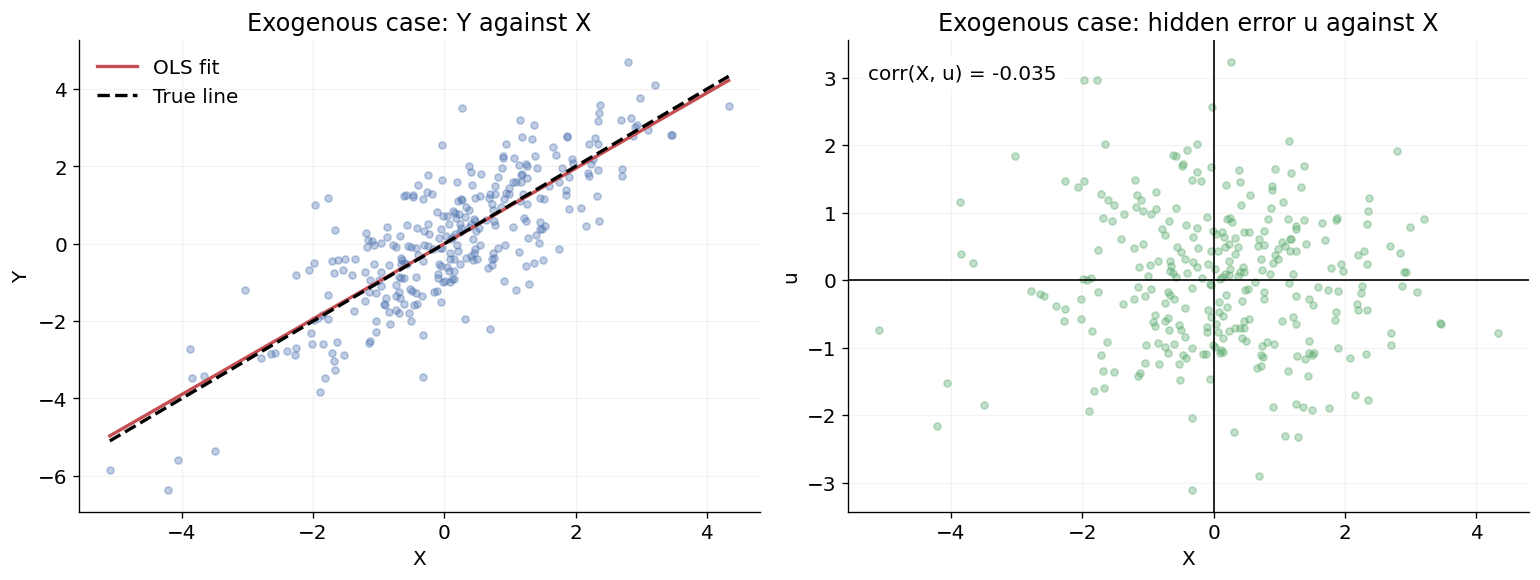

In [3]:
if "lab" not in globals():
    raise RuntimeError("Run the setup cell on the previous slide first.")

beta_true = 1.0

exogenous = lab.sample_basic_endogeneity(
    n=300,
    beta=beta_true,
    gamma=0.0,
    seed=2026,
)

display(lab.basic_case_summary(exogenous, beta_true))
lab.plot_basic_case(exogenous, beta_true, "Exogenous case")

In the summary above, focus on two numbers:

- `corr(X, u)`: it should be close to zero
- `OLS slope`: it should be close to the true slope `beta = 1`

In the right-hand figure we can literally see the hidden error `u` because this is a simulation. In real data we do **not** observe `u`, which is exactly why endogeneity is hard.

## Step 2. Now make the regressor endogenous

In the next cell, `gamma = 0.9`. That means part of `X` is mechanically built from `u`.

,Statistic,Value
0,True beta,1.000
1,OLS slope,1.325
2,Bias,0.325
3,"corr(X, u)",0.551


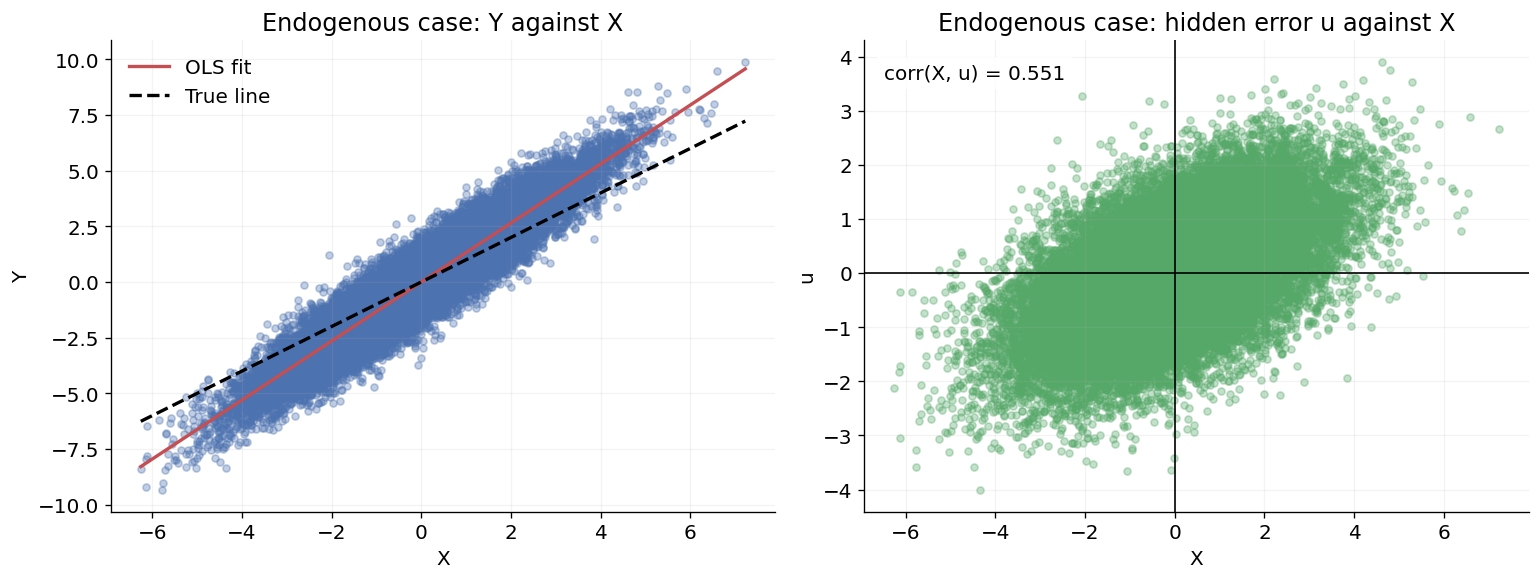

In [8]:
if "lab" not in globals():
    raise RuntimeError("Run the setup cell on the previous slide first.")

endogenous = lab.sample_basic_endogeneity(
    n=30000,
    beta=beta_true,
    gamma=0.95,
    seed=2026,
)

display(lab.basic_case_summary(endogenous, beta_true))
lab.plot_basic_case(endogenous, beta_true, "Endogenous case")

The pictures should now look different:

- `corr(X, u)` is no longer near zero
- the OLS line moves away from the true line

This is the whole problem in one sentence: **OLS is biased because the regressor carries hidden information from the error term.**

## Step 3. Monte Carlo: bias grows as endogeneity gets stronger

One sample can be unlucky. So we repeat the same experiment many times and average the results.

,gamma,"Average corr(X,u)",Mean OLS slope,Bias,Std. dev. of OLS
0,-1.000,-0.575,0.667,-0.333,0.027
1,-0.600,-0.395,0.742,-0.258,0.035
2,-0.300,-0.211,0.854,-0.146,0.040
3,0.000,0.003,1.002,0.002,0.039
4,0.300,0.205,1.142,0.142,0.039
5,0.600,0.387,1.253,0.253,0.035
6,1.000,0.578,1.334,0.334,0.026


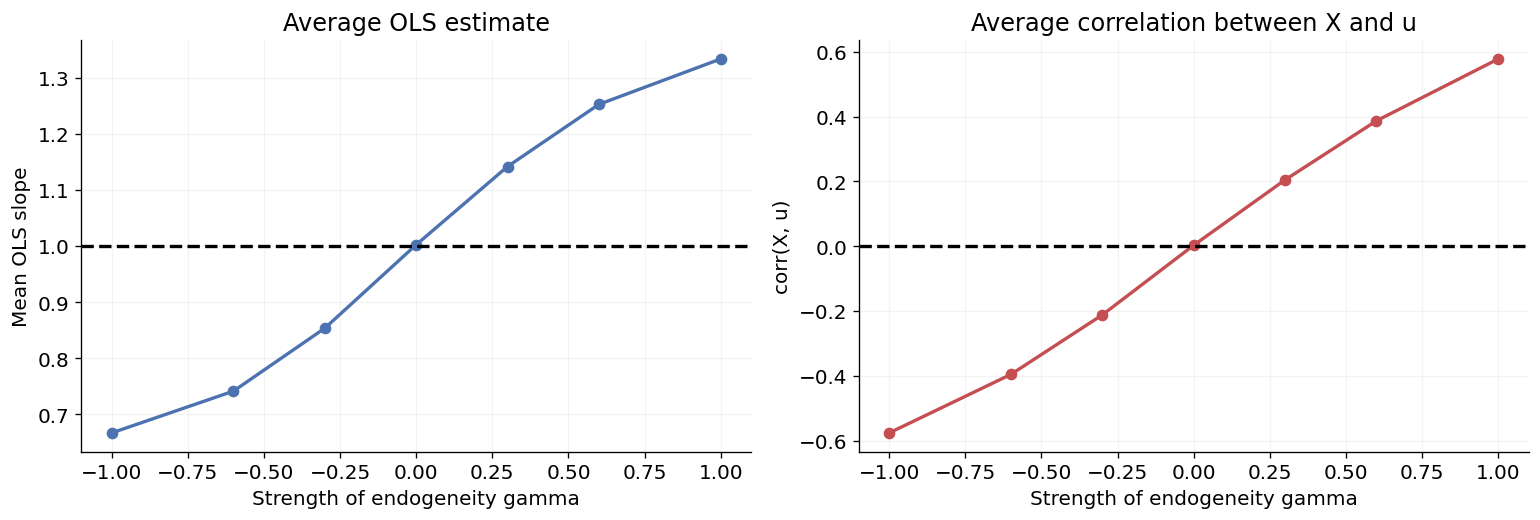

In [9]:
if "lab" not in globals():
    raise RuntimeError("Run the setup cell on the previous slide first.")

gamma_grid = (-1.0, -0.6, -0.3, 0.0, 0.3, 0.6, 1.0)

mc_results = lab.mc_basic_endogeneity(
    n=300,
    beta=beta_true,
    gamma_values=gamma_grid,
    reps=600,
    seed=2026,
)

display(mc_results)
lab.plot_basic_monte_carlo(mc_results, beta_true)

Read the table and figures as follows:

- when `gamma = 0`, the average OLS estimate is close to the truth
- when `gamma > 0`, OLS is biased upward
- when `gamma < 0`, OLS is biased downward

The sign of the bias depends on the sign of the correlation between `X` and `u`.

## What creates endogeneity in practice?

The algebra is always the same: `cov(X, u) != 0`.

But the **mechanism** can differ. In introductory econometrics, the three standard mechanisms are:

1. **Omitted variable bias**: something important is left out of the regression, ends up inside `u`, and is correlated with `X`
2. **Measurement error**: the regressor is measured with noise, so the noise leaks into both `X` and `u`
3. **Simultaneity**: `X` and `Y` are jointly determined, so `X` already reflects shocks hitting `Y`

Notebook 2 studies those three cases one by one.

## Try it yourself

The next cell is meant for students to edit. Change `trial_gamma`, rerun, and watch how the summary table and the figures move.

In [ ]:
if "lab" not in globals():
    raise RuntimeError("Run the setup cell on the previous slide first.")

trial_gamma = 0.4

trial = lab.sample_basic_endogeneity(
    n=300,
    beta=beta_true,
    gamma=trial_gamma,
    seed=99,
)

display(lab.basic_case_summary(trial, beta_true))
lab.plot_basic_case(trial, beta_true, f"Trial case with gamma = {trial_gamma}")

## Takeaway

If `X` is clean, OLS can recover the true slope. If `X` is contaminated by the hidden part of the outcome equation, OLS loses its causal interpretation.

The next notebook answers the natural follow-up question: **what are the concrete economic stories that make `cov(X, u)` nonzero?**